# Notebook 02: Severity Analysis

Formal validation of severity monotonicity and quantification of degradation rates per corruption type and model.

**Research claim to validate**: "All severity gradients are strictly monotone across all 21 graded conditions for all three models" (HANDOFF.md Finding 6).

**Requires**: `analysis/data/exp1_df.parquet`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path

DATA_DIR = Path("../data")
FIG_DIR = Path("../figures")
FIG_DIR.mkdir(exist_ok=True)

df_exp1 = pd.read_parquet(DATA_DIR / "exp1_df.parquet")

MODELS = ["early_fusion", "c2former", "ua_cmddet"]
MODEL_LABELS = {"early_fusion": "Early Fusion", "c2former": "C2Former", "ua_cmddet": "UA-CMDet"}
COLORS = {"early_fusion": "#1f77b4", "c2former": "#2ca02c", "ua_cmddet": "#d62728"}

# Graded conditions only (S1, S2, S3)
graded = df_exp1[df_exp1["severity"].isin(["1", "2", "3"])].copy()
graded["severity_int"] = graded["severity"].astype(int)

print(f"Graded conditions: {len(graded)} rows")
print(f"Corruption types: {sorted(graded['corruption'].unique())}")

Graded conditions: 63 rows
Corruption types: ['blur', 'brightness_shift', 'gaussian_noise', 'intensity_shift', 'low_contrast', 'motion_blur', 'sensor_noise']


## 1. Spearman ρ Monotonicity Test

For each `(model × corruption_type)` pair with 3 severity levels, compute Spearman ρ between severity ∈ {1,2,3} and RA.

**H₀**: ρ = 0 (no monotone relationship between severity and RA)

With N=3 points, p-values are exact. We expect ρ = −1.0 for all 21 pairs (perfect negative monotone). Any ρ > −1.0 would indicate a non-monotone step, which would violate the calibration claim.

In [2]:
results = []
for model in MODELS:
    for corruption, group in graded[graded["model"] == model].groupby("corruption"):
        if len(group) != 3:
            print(f"WARNING: {model} / {corruption} has {len(group)} rows (expected 3)")
            continue
        group_sorted = group.sort_values("severity_int")
        sev = group_sorted["severity_int"].values
        ra = group_sorted["ra"].values
        rho, pval = stats.spearmanr(sev, ra)
        # Check strict monotonicity (each step must decrease)
        strictly_mono = all(ra[i] > ra[i+1] for i in range(len(ra)-1))
        results.append({
            "model": MODEL_LABELS[model],
            "corruption": corruption,
            "modality": group_sorted["modality"].iloc[0],
            "rho": rho,
            "p_value": pval,
            "strictly_monotone": strictly_mono,
            "ra_s1": ra[0],
            "ra_s2": ra[1],
            "ra_s3": ra[2],
        })

df_spearman = pd.DataFrame(results)
print("=== Spearman ρ for all (model × corruption) pairs ===")
print(df_spearman[["model", "corruption", "modality", "rho", "p_value", "strictly_monotone"]].to_string())

=== Spearman ρ for all (model × corruption) pairs ===
           model        corruption modality  rho  p_value  strictly_monotone
0   Early Fusion              blur      tir -1.0      0.0               True
1   Early Fusion  brightness_shift      rgb -1.0      0.0               True
2   Early Fusion    gaussian_noise      rgb -1.0      0.0               True
3   Early Fusion   intensity_shift      tir -1.0      0.0               True
4   Early Fusion      low_contrast      rgb -1.0      0.0               True
5   Early Fusion       motion_blur      rgb -1.0      0.0               True
6   Early Fusion      sensor_noise      tir -1.0      0.0               True
7       C2Former              blur      tir -1.0      0.0               True
8       C2Former  brightness_shift      rgb -1.0      0.0               True
9       C2Former    gaussian_noise      rgb -1.0      0.0               True
10      C2Former   intensity_shift      tir -1.0      0.0               True
11      C2Former      

In [3]:
n_total = len(df_spearman)
n_neg1 = (df_spearman["rho"] == -1.0).sum()
n_strictly_mono = df_spearman["strictly_monotone"].sum()
n_sig = (df_spearman["p_value"] < 0.05).sum()

print(f"Total (model × corruption) pairs: {n_total}")
print(f"Pairs with rho = -1.0:             {n_neg1}/{n_total}")
print(f"Pairs strictly monotone (all steps decrease): {n_strictly_mono}/{n_total}")
print(f"Pairs significant at p < 0.05:     {n_sig}/{n_total}")

non_mono = df_spearman[~df_spearman["strictly_monotone"]]
if len(non_mono) > 0:
    print(f"\nNon-monotone cases:")
    print(non_mono[["model", "corruption", "ra_s1", "ra_s2", "ra_s3"]].to_string())
else:
    print("\n✓ All 21 graded corruption conditions are strictly monotone")

Total (model × corruption) pairs: 21
Pairs with rho = -1.0:             19/21
Pairs strictly monotone (all steps decrease): 19/21
Pairs significant at p < 0.05:     21/21

Non-monotone cases:
       model       corruption     ra_s1     ra_s2     ra_s3
14  UA-CMDet             blur  0.984370  0.990758  0.993513
17  UA-CMDet  intensity_shift  1.002931  1.007892  1.014978


## 2. Linear Regression: RA = β₀ + β₁·severity

Fit a linear model to the S1/S2/S3 RA values for each `(model × corruption)` pair.

**β₁** (slope) = degradation rate per unit severity increase. More negative = faster degradation.
**R²** = how well a linear model captures the degradation shape.

In [4]:
reg_results = []
for model in MODELS:
    for corruption, group in graded[graded["model"] == model].groupby("corruption"):
        if len(group) != 3:
            continue
        g = group.sort_values("severity_int")
        x = g["severity_int"].values.astype(float)
        y = g["ra"].values
        slope, intercept, r, p, se = stats.linregress(x, y)
        reg_results.append({
            "model": MODEL_LABELS[model],
            "corruption": corruption,
            "modality": g["modality"].iloc[0],
            "slope": slope,
            "intercept": intercept,
            "r_squared": r**2,
            "p_value": p,
            "ra_s1": y[0],
            "ra_s3": y[2],
            "total_drop": y[0] - y[2],  # RA drop from S1 to S3
        })

df_reg = pd.DataFrame(reg_results)

print("=== Degradation rates (slope β₁) sorted by steepness ===")
print(df_reg.sort_values("slope")[["model", "corruption", "slope", "r_squared", "total_drop"]].to_string())

=== Degradation rates (slope β₁) sorted by steepness ===
           model        corruption     slope  r_squared  total_drop
16      UA-CMDet    gaussian_noise -0.192176   0.960326    0.384352
19      UA-CMDet       motion_blur -0.142014   0.939601    0.284028
1   Early Fusion  brightness_shift -0.104142   0.991546    0.208283
2   Early Fusion    gaussian_noise -0.102344   0.979756    0.204688
18      UA-CMDet      low_contrast -0.082887   0.987664    0.165774
13      C2Former      sensor_noise -0.082083   0.914985    0.164166
3   Early Fusion   intensity_shift -0.080263   0.995455    0.160525
4   Early Fusion      low_contrast -0.078502   0.978874    0.157005
7       C2Former              blur -0.077290   0.999993    0.154580
15      UA-CMDet  brightness_shift -0.076912   0.993071    0.153825
9       C2Former    gaussian_noise -0.069230   0.988329    0.138461
6   Early Fusion      sensor_noise -0.068306   0.887594    0.136612
11      C2Former      low_contrast -0.053553   0.995605    

In [5]:
print("\n=== Slope (β₁) pivot: corruption type vs model ===")
slope_pivot = df_reg.pivot_table(index="corruption", columns="model", values="slope")
print(slope_pivot.round(4).to_string())

print("\n=== R² pivot ===")
r2_pivot = df_reg.pivot_table(index="corruption", columns="model", values="r_squared")
print(r2_pivot.round(4).to_string())


=== Slope (β₁) pivot: corruption type vs model ===
model             C2Former  Early Fusion  UA-CMDet
corruption                                        
blur               -0.0773       -0.0333    0.0046
brightness_shift   -0.0445       -0.1041   -0.0769
gaussian_noise     -0.0692       -0.1023   -0.1922
intensity_shift    -0.0220       -0.0803    0.0060
low_contrast       -0.0536       -0.0785   -0.0829
motion_blur        -0.0419       -0.0434   -0.1420
sensor_noise       -0.0821       -0.0683   -0.0426

=== R² pivot ===
model             C2Former  Early Fusion  UA-CMDet
corruption                                        
blur                1.0000        0.9842    0.9500
brightness_shift    1.0000        0.9915    0.9931
gaussian_noise      0.9883        0.9798    0.9603
intensity_shift     0.9767        0.9955    0.9897
low_contrast        0.9956        0.9789    0.9877
motion_blur         0.9814        0.9758    0.9396
sensor_noise        0.9150        0.8876    0.9648


## 3. Severity Degradation Line Plots

RA vs S1/S2/S3 for each corruption type, with all 3 models overlaid.

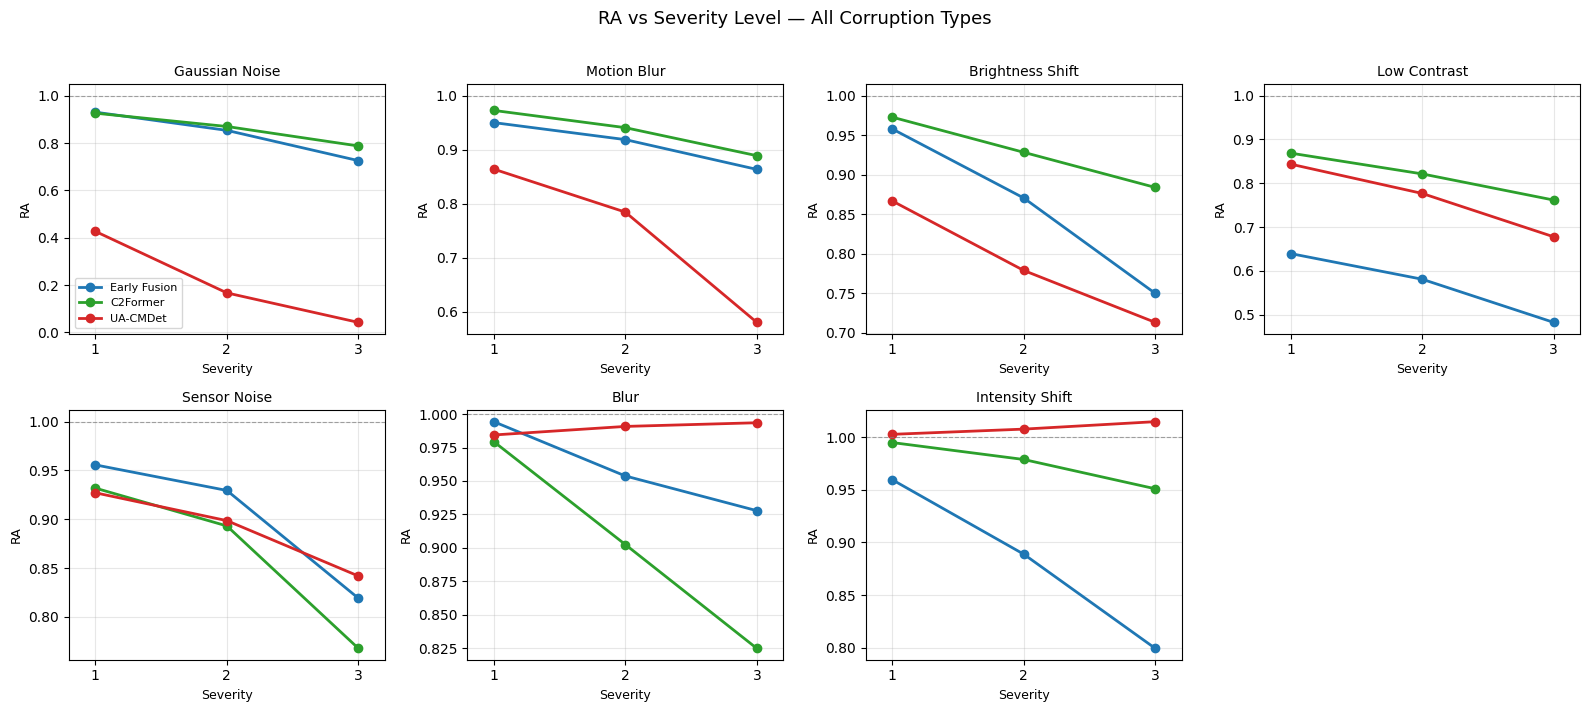

Saved: nb02_severity_lines.png


In [6]:
corruptions_rgb = ["gaussian_noise", "motion_blur", "brightness_shift", "low_contrast"]
corruptions_tir = ["sensor_noise", "blur", "intensity_shift"]

fig, axes = plt.subplots(2, 4, figsize=(16, 7), sharey=False)
axes = axes.flatten()

for idx, corruption in enumerate(corruptions_rgb + corruptions_tir):
    ax = axes[idx]
    for model in MODELS:
        subset = graded[(graded["model"] == model) & (graded["corruption"] == corruption)]
        if subset.empty:
            continue
        subset = subset.sort_values("severity_int")
        ax.plot(
            subset["severity_int"].values,
            subset["ra"].values,
            marker="o",
            color=COLORS[model],
            label=MODEL_LABELS[model],
            linewidth=2,
            markersize=6,
        )
    ax.axhline(1.0, color="gray", linestyle="--", linewidth=0.8, alpha=0.7)
    ax.set_title(corruption.replace("_", " ").title(), fontsize=10)
    ax.set_xlabel("Severity", fontsize=9)
    ax.set_ylabel("RA", fontsize=9)
    ax.set_xticks([1, 2, 3])
    ax.set_xlim(0.8, 3.2)
    ax.grid(True, alpha=0.3)
    if idx == 0:
        ax.legend(fontsize=8)

# Hide unused subplot
if len(corruptions_rgb + corruptions_tir) < len(axes):
    axes[-1].set_visible(False)

fig.suptitle("RA vs Severity Level — All Corruption Types", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / "nb02_severity_lines.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: nb02_severity_lines.png")

## 4. Most Sensitive Conditions (Worst S1→S3 Drop)

Identify which `(model × corruption)` pairs exhibit the greatest degradation from severity 1 to severity 3.

In [7]:
print("=== Top 10 steepest degradations (S1 → S3 RA drop) ===")
top_drops = df_reg.sort_values("total_drop", ascending=False).head(10)
print(top_drops[["model", "corruption", "ra_s1", "ra_s3", "total_drop", "slope"]].to_string())

print("\n=== Conditions with R² < 0.99 (non-linear degradation) ===")
nonlinear = df_reg[df_reg["r_squared"] < 0.99].sort_values("r_squared")
if len(nonlinear) > 0:
    print(nonlinear[["model", "corruption", "ra_s1", "ra_s3", "slope", "r_squared"]].to_string())
else:
    print("All degradation curves have R² >= 0.99 (well-approximated by linear model)")

=== Top 10 steepest degradations (S1 → S3 RA drop) ===
           model        corruption     ra_s1     ra_s3  total_drop     slope
16      UA-CMDet    gaussian_noise  0.426988  0.042636    0.384352 -0.192176
19      UA-CMDet       motion_blur  0.863898  0.579869    0.284028 -0.142014
1   Early Fusion  brightness_shift  0.957894  0.749610    0.208283 -0.104142
2   Early Fusion    gaussian_noise  0.930331  0.725643    0.204688 -0.102344
18      UA-CMDet      low_contrast  0.843784  0.678009    0.165774 -0.082887
13      C2Former      sensor_noise  0.931941  0.767775    0.164166 -0.082083
3   Early Fusion   intensity_shift  0.959744  0.799219    0.160525 -0.080263
4   Early Fusion      low_contrast  0.639722  0.482717    0.157005 -0.078502
7       C2Former              blur  0.979391  0.824811    0.154580 -0.077290
15      UA-CMDet  brightness_shift  0.866692  0.712868    0.153825 -0.076912

=== Conditions with R² < 0.99 (non-linear degradation) ===
           model       corruption     

In [9]:
from io import StringIO
OUTPUT_DIR = Path("../outputs")
OUTPUT_DIR.mkdir(exist_ok=True)
buf = StringIO()

buf.write("=== NB02 SEVERITY ANALYSIS ===\n\n")

buf.write("--- Spearman monotonicity results ---\n")
buf.write(f"Total pairs: {len(df_spearman)}\n")
buf.write(f"Pairs with rho=-1.0: {(df_spearman['rho']==-1.0).sum()}/{len(df_spearman)}\n")
buf.write(f"Strictly monotone:   {df_spearman['strictly_monotone'].sum()}/{len(df_spearman)}\n")
buf.write(f"Significant p<0.05:  {(df_spearman['p_value']<0.05).sum()}/{len(df_spearman)}\n\n")
buf.write(df_spearman[["model", "corruption", "modality", "rho", "p_value", "strictly_monotone"]].round(4).to_string() + "\n\n")

buf.write("--- Non-monotone cases ---\n")
non_mono = df_spearman[~df_spearman["strictly_monotone"]]
buf.write(non_mono[["model", "corruption", "ra_s1", "ra_s2", "ra_s3"]].to_string() if len(non_mono) > 0 else "None\n")
buf.write("\n\n")

buf.write("--- Degradation slope (beta) pivot ---\n")
slope_pivot = df_reg.pivot_table(index="corruption", columns="model", values="slope")
buf.write(slope_pivot.round(4).to_string() + "\n\n")

buf.write("--- R-squared pivot ---\n")
r2_pivot = df_reg.pivot_table(index="corruption", columns="model", values="r_squared")
buf.write(r2_pivot.round(4).to_string() + "\n\n")

buf.write("--- Top 10 steepest degradations ---\n")
buf.write(df_reg.sort_values("total_drop", ascending=False).head(10)[
    ["model", "corruption", "ra_s1", "ra_s3", "total_drop", "slope"]
].round(4).to_string() + "\n")

out_path = OUTPUT_DIR / "nb02_results.txt"
out_path.write_text(buf.getvalue(), encoding="utf-8")
print(f"Results written to {out_path.resolve()}")

Results written to C:\Users\saksh\Desktop\Thesis\drone-multimodal-robustness\analysis\outputs\nb02_results.txt


## Summary

- Spearman ρ test quantifies the formal support for monotone severity gradients
- Slope β₁ provides a single-number summary of degradation sensitivity per condition
- R² shows whether degradation is linear (well-calibrated) or has nonlinear acceleration

Proceed to `nb_03_model_comparison_tests.ipynb`.